In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Settings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# List to store results for comparison later
model_results = []

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load dataset
try:
    data = pd.read_csv('data.csv')
    print(f"Dataset shape: {data.shape}")
except:
    print("Error: data.csv not found.")

# Cleaning column names
data.columns = data.columns.str.strip().str.replace(" " ,"_")
data.rename(columns = {'Bankrupt?' :'Bankrupt' }, inplace=True)

# Dropping constant column
if 'Net_Income_Flag' in data.columns:
    data.drop(['Net_Income_Flag'], axis=1, inplace=True)

# Log Transformation for skewed features
print("Processing features (Log transformation)...")
fractional_cols = []
for col in data.drop(['Bankrupt'], axis=1).columns:
    if (data[col].max()<=1) & (data[col].min() >= 0):
        fractional_cols.append(col)

non_fraction_cols = data.drop(['Bankrupt'], axis=1).columns.difference(fractional_cols)

for col in non_fraction_cols:
    # Applying log if values are extreme
    if (data[col].quantile(1) >= 100 * data[col].quantile(0.99)) | (sum(data[col] > data[col].quantile(0.99)) <= 10):
        data[col] = np.log1p(data[col])

print("Data cleaning done.")

Dataset shape: (6819, 96)
Processing features (Log transformation)...
Data cleaning done.


Bankrupt
0    6599
1     220
Name: count, dtype: int64


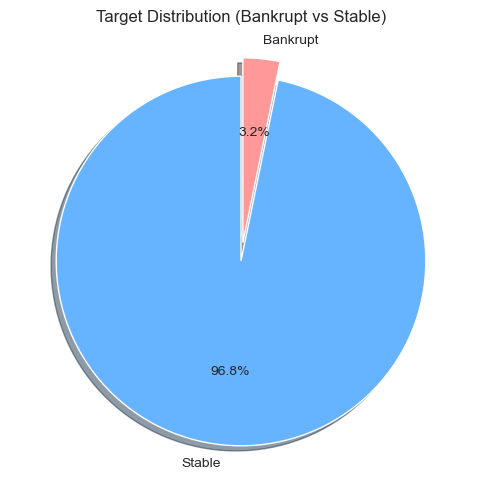

In [3]:
# Checking for data imbalance
target_count = data['Bankrupt'].value_counts()
print(target_count)

plt.figure(figsize=(6, 6))
plt.pie(target_count, labels=['Stable', 'Bankrupt'], autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1), shadow=True)
plt.title("Target Distribution (Bankrupt vs Stable)")
plt.show()

Top correlated features: ['Debt_ratio_%', 'Current_Liability_to_Assets', 'Borrowing_dependency', 'Current_Liability_to_Current_Assets', 'Liability_to_Equity']


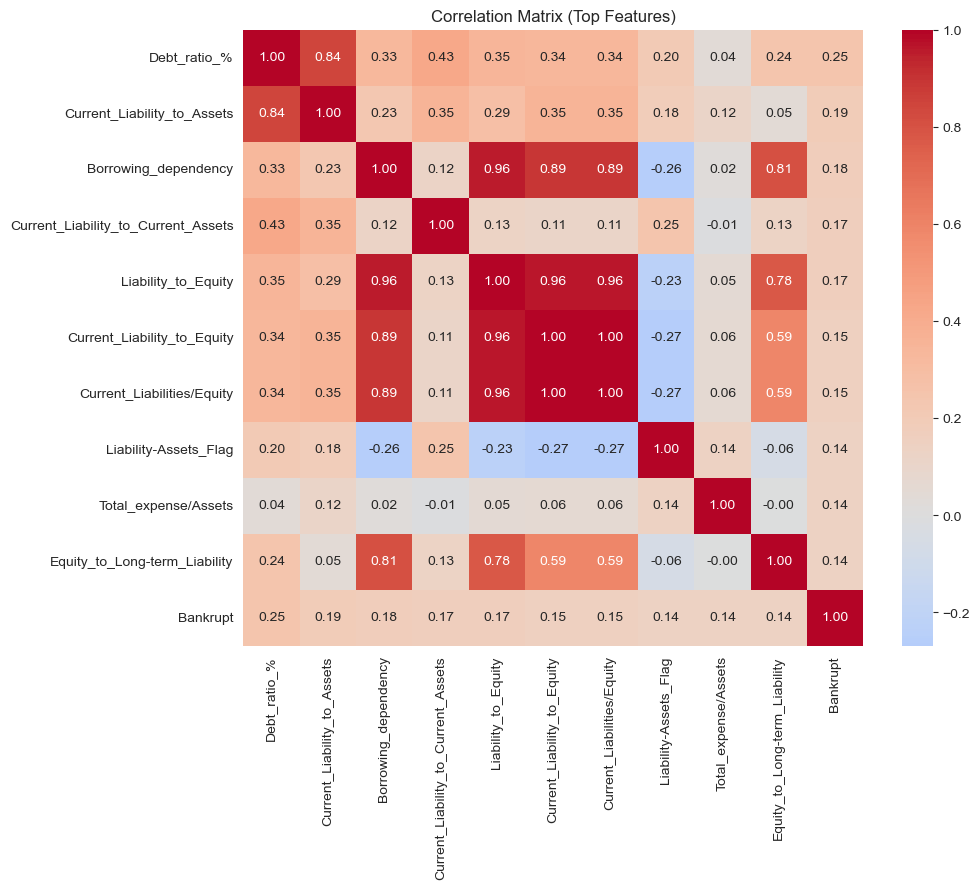

In [4]:
# Checking correlations with target
corr_matrix = data.corr()
target_corr = corr_matrix['Bankrupt'].sort_values(ascending=False)

# Get top 10 positive and negative correlations
top_features = target_corr.index[1:11].tolist() 
print("Top correlated features:", top_features[:5])

# Plot heatmap for top features
plt.figure(figsize=(10, 8))
sns.heatmap(data[top_features + ['Bankrupt']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Matrix (Top Features)")
plt.show()

In [5]:
X = data.drop(["Bankrupt"], axis=1)
y = data.Bankrupt

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (5455, 94)
Test set: (1364, 94)


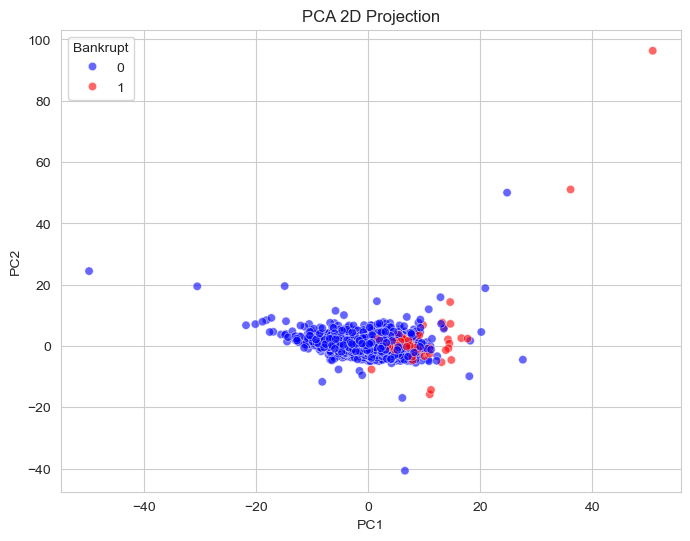

In [6]:
# Scaling then PCA
scaler_vis = StandardScaler()
X_train_scaled = scaler_vis.fit_transform(X_train)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, palette={0:'blue', 1:'red'}, alpha=0.6)
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# Logistic Regression
print("Training Logistic Regression...")
lr_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000))
])
lr_pipe.fit(X_train, y_train)

# Save metrics
lr_prob = lr_pipe.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)
fpr, tpr, _ = roc_curve(y_test, lr_prob)
model_results.append({'model': "Logistic Regression", 'fpr': fpr, 'tpr': tpr, 'auc': lr_auc})


# Support Vector Machine (SVM)
print("Training SVM...")
svm_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(probability=True, random_state=42)) 
])
svm_pipe.fit(X_train, y_train)

# Save metrics
svm_prob = svm_pipe.predict_proba(X_test)[:,1]
svm_auc = roc_auc_score(y_test, svm_prob)
fpr, tpr, _ = roc_curve(y_test, svm_prob)
model_results.append({'model': "SVM", 'fpr': fpr, 'tpr': tpr, 'auc': svm_auc})

print("Baselines trained.")

Training Logistic Regression...


  File "c:\Users\Thibault\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Thibault\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Thibault\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Thibault\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Training SVM...
Baselines trained.


In [8]:
print("Tuning Random Forest with GridSearchCV...")

# Base pipeline
rf_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    # We use class_weight balanced here instead of SMOTE for variety
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Parameters to test
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
rf_best = grid.best_estimator_
print(f"Best params: {grid.best_params_}")

# Save metrics
rf_prob = rf_best.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)
fpr, tpr, _ = roc_curve(y_test, rf_prob)
model_results.append({'model': "Random Forest (Tuned)", 'fpr': fpr, 'tpr': tpr, 'auc': rf_auc})

Tuning Random Forest with GridSearchCV...
Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}


In [9]:
print("Training Gradient Boosting...")

gb_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
gb_pipe.fit(X_train, y_train)

# Save metrics
gb_prob = gb_pipe.predict_proba(X_test)[:,1]
gb_auc = roc_auc_score(y_test, gb_prob)
fpr, tpr, _ = roc_curve(y_test, gb_prob)
model_results.append({'model': "Gradient Boosting", 'fpr': fpr, 'tpr': tpr, 'auc': gb_auc})

Training Gradient Boosting...


In [10]:
print("Training Voting Classifier...")

# We combine LR, the Tuned RF, and Gradient Boosting
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_best),
        ('gb', gb_pipe)
    ],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

# Save metrics
vot_prob = voting_clf.predict_proba(X_test)[:,1]
vot_auc = roc_auc_score(y_test, vot_prob)
fpr, tpr, _ = roc_curve(y_test, vot_prob)
model_results.append({'model': "Voting Classifier", 'fpr': fpr, 'tpr': tpr, 'auc': vot_auc})
print(f"Voting AUC: {vot_auc:.4f}")

Training Voting Classifier...
Voting AUC: 0.9470


In [11]:
print("Training Stacking Classifier...")

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', rf_best),
        ('gb', gb_pipe)
    ],
    final_estimator=LogisticRegression(),
    cv=3
)
stacking_clf.fit(X_train, y_train)

# Save metrics
stack_prob = stacking_clf.predict_proba(X_test)[:,1]
stack_auc = roc_auc_score(y_test, stack_prob)
fpr, tpr, _ = roc_curve(y_test, stack_prob)
model_results.append({'model': "Stacking", 'fpr': fpr, 'tpr': tpr, 'auc': stack_auc})
print(f"Stacking AUC: {stack_auc:.4f}")

Training Stacking Classifier...
Stacking AUC: 0.9556
